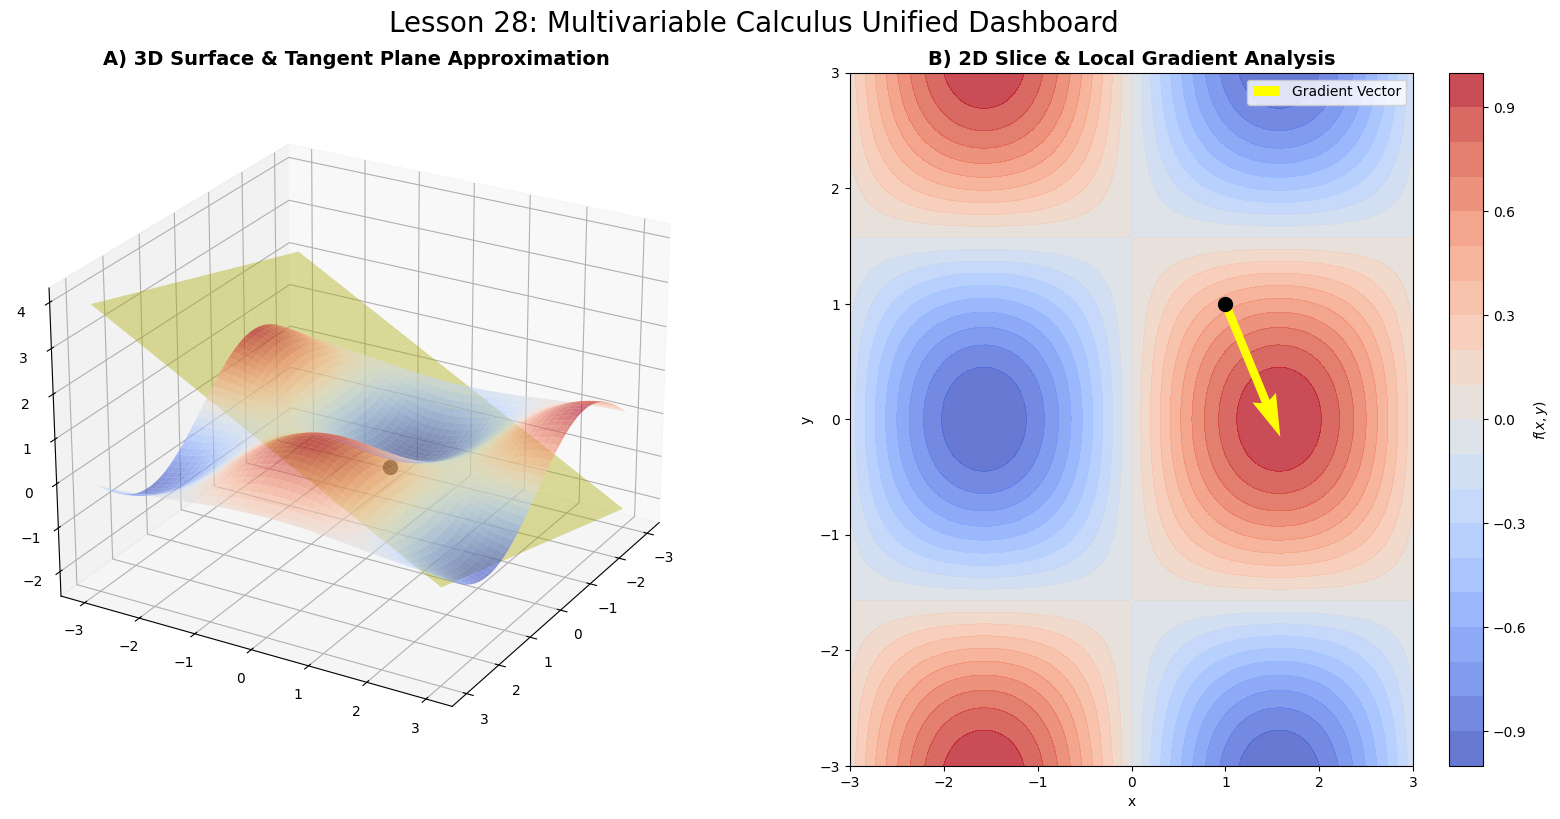

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_partial_derivative_dashboard():
    # Fonksiyon: f(x,y) = sin(x) * cos(y)
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X) * np.cos(Y)

    # Teğet noktası seçimi (Ph.D. Dokunuşu: P(1, 1))
    a, b = 1.0, 1.0
    fa_b = np.sin(a) * np.cos(b)
    # Kısmi türevler: fx = cos(x)cos(y), fy = -sin(x)sin(y)
    fx = np.cos(a) * np.cos(b)
    fy = -np.sin(a) * np.sin(b)

    # Teğet Düzlemi Denklemi: z = f(a,b) + fx(x-a) + fy(y-b)
    Z_plane = fa_b + fx*(X - a) + fy*(Y - b)

    fig = plt.figure(figsize=(20, 9))

    # --- 1. Subplot: 3D Surface & Tangent Plane ---
    ax1 = fig.add_subplot(121, projection='3d')
    # Ana yüzey
    surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.6, edgecolor='none')
    # Teğet Düzlemi (Sarı renkte, yarı saydam)
    ax1.plot_surface(X, Y, Z_plane, color='yellow', alpha=0.4, label='Tangent Plane')
    # Teğet noktası
    ax1.scatter([a], [b], [fa_b], color='black', s=100, label=f'Point P({a},{b})')
    
    ax1.set_title("A) 3D Surface & Tangent Plane Approximation", fontsize=14, fontweight='bold')
    ax1.view_init(elev=25, azim=30)

    # --- 2. Subplot: 2D Slice Analysis (Contour & Gradient) ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X, Y, Z, 20, cmap='coolwarm', alpha=0.8)
    fig.colorbar(contour, ax=ax2, label='$f(x, y)$')
    # Teğet noktasını işaretle
    ax2.plot(a, b, 'ko', markersize=10)
    # Gradyan vektörünü çiz (fx ve fy yönünde)
    ax2.quiver(a, b, fx, fy, color='yellow', scale=3, width=0.015, label='Gradient Vector')
    
    ax2.set_title("B) 2D Slice & Local Gradient Analysis", fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    plt.suptitle("Lesson 28: Multivariable Calculus Unified Dashboard", fontsize=20, y=0.95)
    
    if not os.path.exists('../../../assets'): os.makedirs('../../../assets')
    plt.savefig('../../../assets/28_tangent_plane.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    run_partial_derivative_dashboard()